In [15]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib_venn import venn2

fsize = 20
plt.rcParams.update({"font.size": fsize})
%config InlineBackend.figure_format = 'retina'

In [16]:
def load_human_evidence(fn):
    # we only want derived since we're going to compare gene ids
    df = pd.read_json(fn)
    derived_df = df['derived'].apply(pd.Series)
    return derived_df

def load_deg_evidence(fn):
    df = pd.read_json(fn)
    df = df.apply(pd.Series)
    return df

In [17]:
fn_human = "../../data/bone_He2021/evidence_human/evidence.json"
fn_deg = "../../data/bone_He2021/evidence_deg/evidence.json"

derived_human_ev = load_human_evidence(fn_human)
deg_ev = load_deg_evidence(fn_deg)

deg_ev

,cell_type_label,gene,organism,cell_source,cell_state,gene_id
0,LBM1,PMAIP1,homo_sapiens,bone,NaN,ENSG00000141682
1,LBM1,VEGFD,homo_sapiens,bone,NaN,ENSG00000165197
2,LBM1,LHX2,homo_sapiens,bone,NaN,ENSG00000106689
3,LBM1,MYCN,homo_sapiens,bone,NaN,ENSG00000134323
4,LBM1,MSX1,homo_sapiens,bone,NaN,ENSG00000163132
...,...,...,...,...,...,...
367,Endothelium,SULT1C4,homo_sapiens,bone,NaN,ENSG00000198075
368,Endothelium,TSPAN15,homo_sapiens,bone,NaN,ENSG00000099282
369,Endothelium,THSD1,homo_sapiens,bone,NaN,ENSG00000136114
370,Endothelium,SMTN,homo_sapiens,bone,NaN,ENSG00000183963


## Set Operations

In [18]:
def set_itx(a, b):
    return np.intersect1d(a, b).shape[0]
def set_itx_vals(a,b):
    return np.intersect1d(a,b)
def set_diff(a, b):
    return a.shape[0] - set_itx(a, b)
def create_venn(left, right, itx, set_a_name = "Set A", set_b_name = "Set B"):
    venn2(subsets = (left, right, itx), set_labels = (set_a_name, set_b_name))
    plt.show()

## Global Gene Comparison

In [19]:
feature = "gene_id"

first = derived_human_ev[feature].str.strip().str.upper()
second = deg_ev[feature].str.strip().str.upper()

left  = set_diff(first, second)
itx   = set_itx(first, second)
right = set_diff(second, first)
itx_vals = set_itx_vals(first, second)

393 5 367 ['ENSG00000125378' 'ENSG00000163132' 'ENSG00000166426' 'ENSG00000172789'
 'ENSG00000197757']


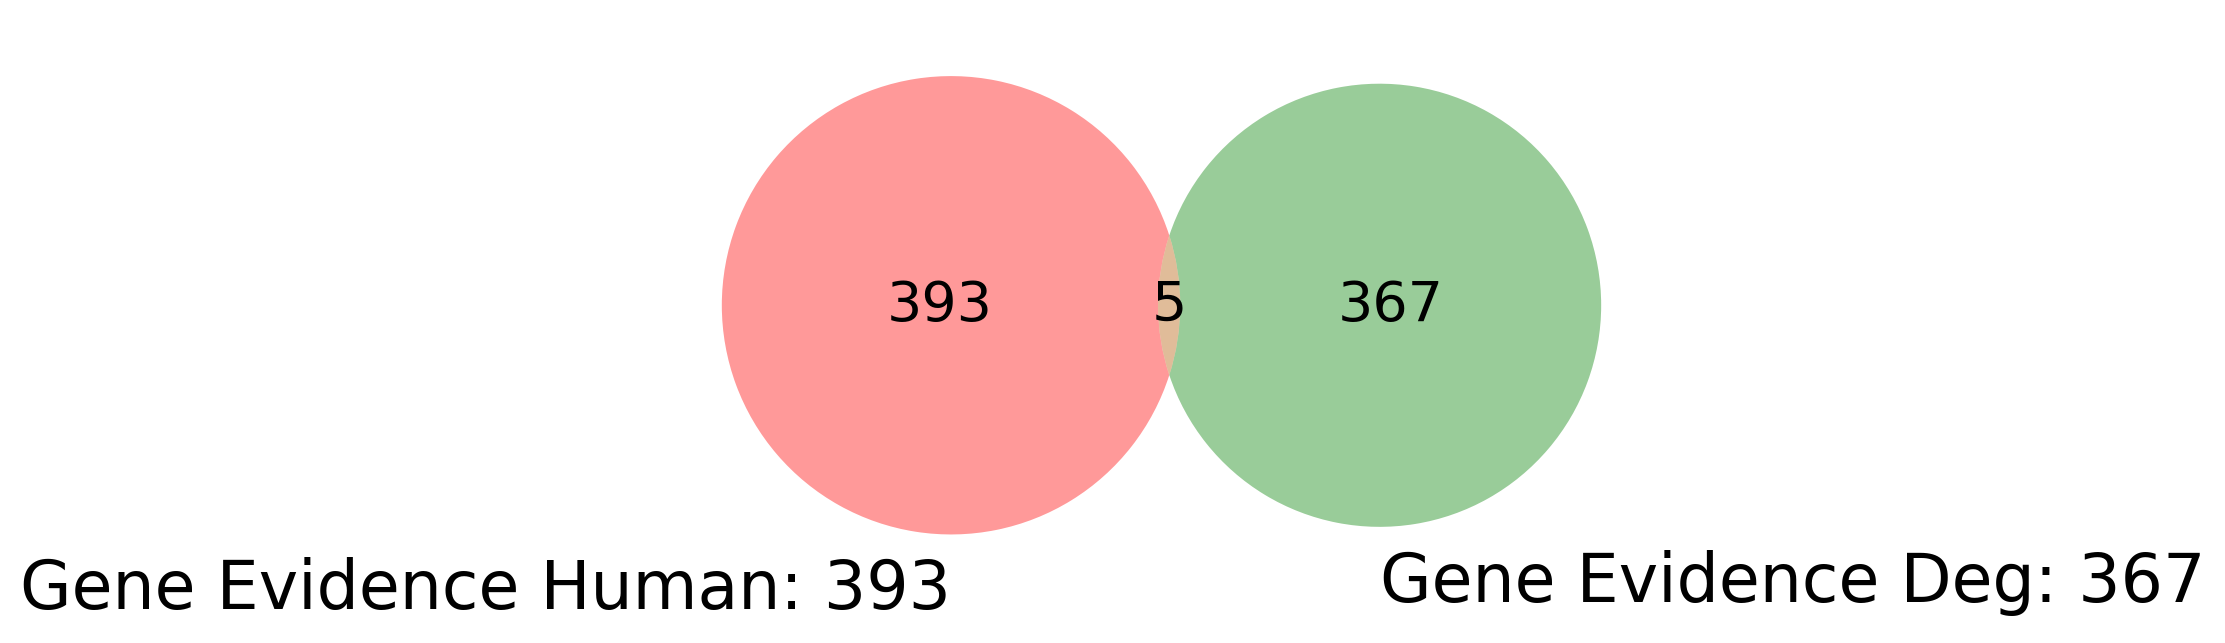

In [20]:
print(left, itx, right, itx_vals)
create_venn(left, right, itx, f'Gene Evidence Human: {left}', f'Gene Evidence Deg: {right}')

## Global Celltype Comparison

In [21]:
feature = "cell_type_label" # eventually change this to comparing based on a map we can create

first = derived_human_ev[feature].str.strip().str.upper()
second = deg_ev[feature].str.strip().str.upper()

left  = set_diff(first, second)
itx   = set_itx(first, second)
right = set_diff(second, first)
itx_vals = set_itx_vals(first, second)

381 17 355 ['CHONDROBLAST' 'CHONDROCYTE' 'ENDOTHELIUM' 'ERYTHROCYTE' 'MACROPHAGE'
 'MIG_NC' 'MYOCYTE' 'MYOPROGENITOR' 'NC' 'NCDC' 'OCP' 'OSTEOPROGENITOR'
 'PERICYTE' 'PMSC' 'PMSC1' 'PMSC2' 'VLMC']


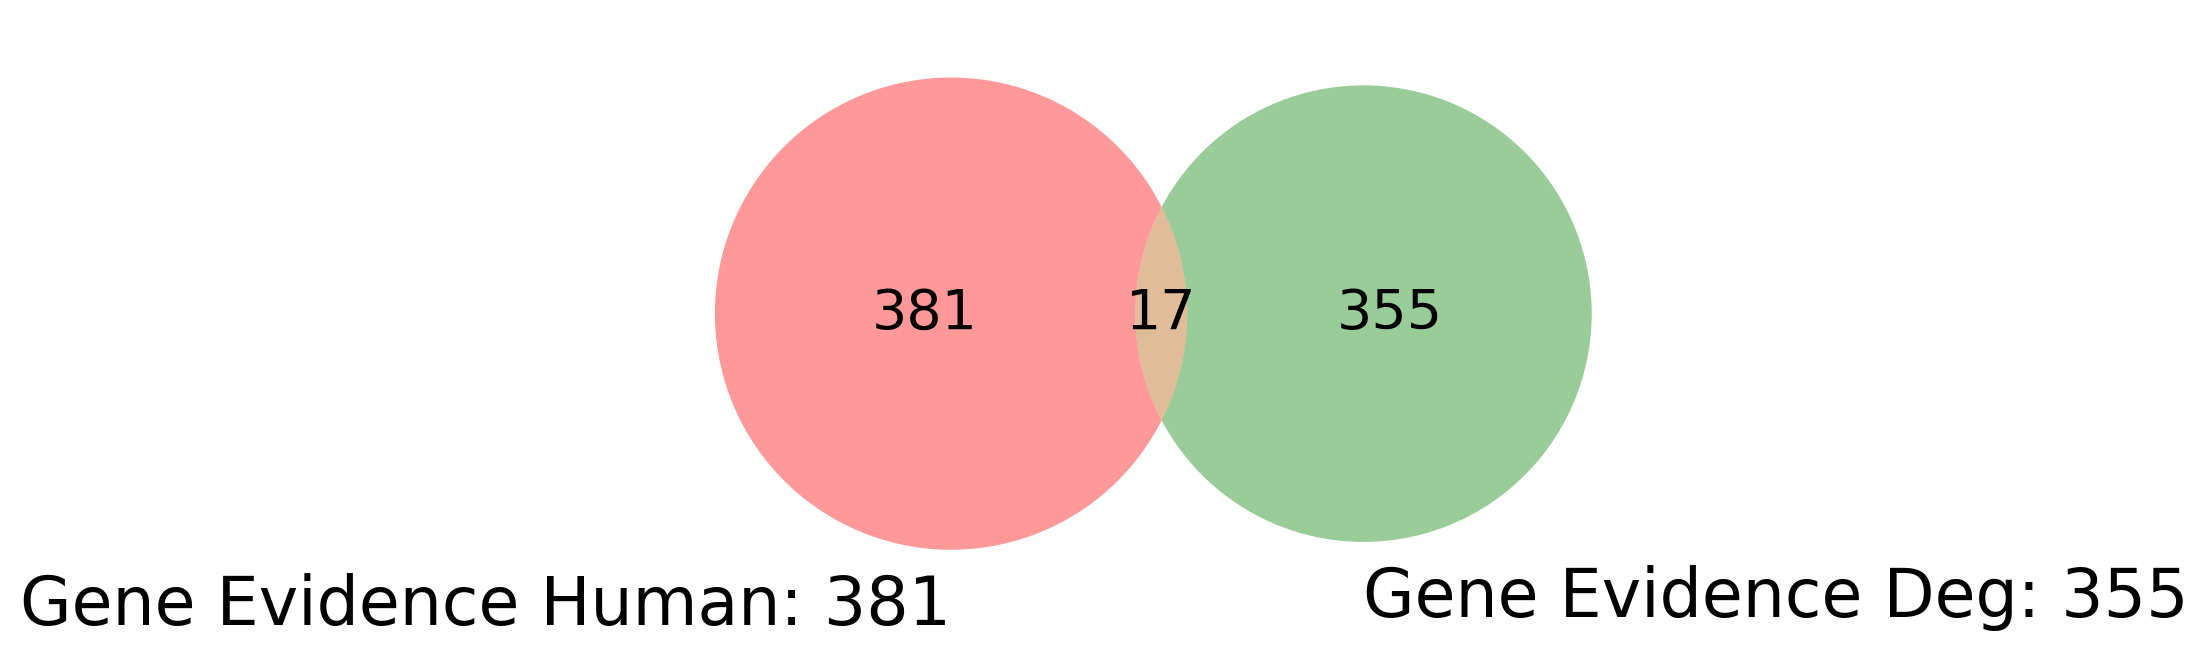

In [22]:
print(left, itx, right, itx_vals)
create_venn(left, right, itx, f'Gene Evidence Human: {left}', f'Gene Evidence Deg: {right}')

## Set Difference + Intersection of Gene Expression Between All Cells in Evidence Deg and Evidence Human

In [23]:
def make_3d_matrix(human_fn, deg_fn):
    """
    Finds similarites in gene expression between all cells mentioned in evidence deg and evidence human and returns a 3D matrix describing the left difference, intersection, and right difference in gene expression.

    Returns:
        pd.DataFrame: the 3D matrix describing set difference and intersection in gene expression
    """

    human_ev = load_human_evidence(human_fn) # gets only the derived part of evidence.json in evidence_human
    deg_ev = load_deg_evidence(deg_fn) 

    feature = "cell_type_label"

    # x axis is human evidence and y axis is deg evidence

    x_labels = sorted(human_ev[feature].unique())
    y_labels = sorted(deg_ev[feature].unique())

    result_df = pd.DataFrame(index = x_labels, columns=y_labels, dtype=object)

    for x in x_labels:
        for y in y_labels:
            genes1 = set(human_ev[human_ev[feature] == x]['gene_id'])
            genes2 = set(deg_ev[deg_ev[feature] == y]['gene_id'])

            left_diff = genes1 - genes2
            intersection = genes1 & genes2
            right_diff = genes2 - genes1

            result_df.loc[x,y] = [left_diff, intersection, right_diff]

    return result_df

In [24]:
matrix = make_3d_matrix(fn_human, fn_deg)

matrix

,BMSC,Chondroblast,Chondrocyte,Chondrocyteblast,Endothelium,Epithelium1,Erythrocyte,LBM1,LBM3,Macrophage,...,OCP,Osteoprogenitor,PMSC,PMSC1,PMSC2,Pericyte,Schwann,VLMC,eSSPC,mig_NC
Calvarial Osteoprogenitor Cell,"[{ENSG00000167157, ENSG00000108821, ENSG000001...","[{ENSG00000167157, ENSG00000108821, ENSG000001...","[{ENSG00000167157, ENSG00000108821, ENSG000001...","[{ENSG00000167157, ENSG00000108821, ENSG000001...","[{ENSG00000167157, ENSG00000108821, ENSG000001...","[{ENSG00000167157, ENSG00000108821, ENSG000001...","[{ENSG00000167157, ENSG00000108821, ENSG000001...","[{ENSG00000167157, ENSG00000108821, ENSG000001...","[{ENSG00000167157, ENSG00000108821, ENSG000001...","[{ENSG00000167157, ENSG00000108821, ENSG000001...",...,"[{ENSG00000167157, ENSG00000108821, ENSG000001...","[{ENSG00000167157, ENSG00000108821, ENSG000001...","[{ENSG00000167157, ENSG00000108821, ENSG000001...","[{ENSG00000167157, ENSG00000108821, ENSG000001...","[{ENSG00000167157, ENSG00000108821, ENSG000001...","[{ENSG00000167157, ENSG00000108821, ENSG000001...","[{ENSG00000167157, ENSG00000108821, ENSG000001...","[{ENSG00000167157, ENSG00000108821, ENSG000001...","[{ENSG00000167157, ENSG00000108821, ENSG000001...","[{ENSG00000167157, ENSG00000108821, ENSG000001..."
Chondroblast,"[{ENSG00000078399, ENSG00000114554, ENSG000001...","[{ENSG00000078399, ENSG00000114554, ENSG000001...","[{ENSG00000078399, ENSG00000114554, ENSG000001...","[{ENSG00000078399, ENSG00000114554, ENSG000001...","[{ENSG00000078399, ENSG00000114554, ENSG000001...","[{ENSG00000078399, ENSG00000114554, ENSG000001...","[{ENSG00000078399, ENSG00000114554, ENSG000001...","[{ENSG00000078399, ENSG00000114554, ENSG000001...","[{ENSG00000078399, ENSG00000114554, ENSG000001...","[{ENSG00000078399, ENSG00000114554, ENSG000001...",...,"[{ENSG00000078399, ENSG00000114554, ENSG000001...","[{ENSG00000078399, ENSG00000114554, ENSG000001...","[{ENSG00000078399, ENSG00000114554, ENSG000001...","[{ENSG00000078399, ENSG00000114554, ENSG000001...","[{ENSG00000078399, ENSG00000114554, ENSG000001...","[{ENSG00000078399, ENSG00000114554, ENSG000001...","[{ENSG00000078399, ENSG00000114554, ENSG000001...","[{ENSG00000078399, ENSG00000114554, ENSG000001...","[{ENSG00000078399, ENSG00000114554, ENSG000001...","[{ENSG00000078399, ENSG00000114554, ENSG000001..."
Chondroblast 7,"[{ENSG00000125398}, {}, {ENSG00000113296, ENSG...","[{ENSG00000125398}, {}, {ENSG00000164929, ENSG...","[{ENSG00000125398}, {}, {ENSG00000163710, ENSG...","[{ENSG00000125398}, {}, {ENSG00000100300, ENSG...","[{ENSG00000125398}, {}, {ENSG00000184588, ENSG...","[{ENSG00000125398}, {}, {ENSG00000130702, ENSG...","[{ENSG00000125398}, {}, {ENSG00000100351, ENSG...","[{ENSG00000125398}, {}, {ENSG00000134323, ENSG...","[{ENSG00000125398}, {}, {ENSG00000177508, ENSG...","[{ENSG00000125398}, {}, {ENSG00000100906, ENSG...",...,"[{ENSG00000125398}, {}, {ENSG00000172939, ENSG...","[{ENSG00000125398}, {}, {ENSG00000213316, ENSG...","[{ENSG00000125398}, {}, {ENSG00000128422, ENSG...","[{ENSG00000125398}, {}, {ENSG00000090530, ENSG...","[{ENSG00000125398}, {}, {ENSG00000140285, ENSG...","[{ENSG00000125398}, {}, {ENSG00000133121, ENSG...","[{ENSG00000125398}, {}, {ENSG00000138760, ENSG...","[{ENSG00000125398}, {}, {ENSG00000196358, ENSG...","[{ENSG00000125398}, {}, {ENSG00000162188}]","[{ENSG00000125398}, {}, {ENSG00000138772, ENSG..."
Chondrocyte,"[{ENSG00000078399, ENSG00000125398, ENSG000002...","[{ENSG00000078399, ENSG00000125398, ENSG000002...","[{ENSG00000078399, ENSG00000125398, ENSG000002...","[{ENSG00000078399, ENSG00000125398, ENSG000002...","[{ENSG00000078399, ENSG00000125398, ENSG000002...","[{ENSG00000078399, ENSG00000125398, ENSG000002...","[{ENSG00000078399, ENSG00000125398, ENSG000002...","[{ENSG00000078399, ENSG00000125398, ENSG000002...","[{ENSG00000078399, ENSG00000125398, ENSG000002...","[{ENSG00000078399, ENSG00000125398, ENSG000002...",...,"[{ENSG00000078399, ENSG00000125398, ENSG000002...","[{ENSG00000078399, ENSG00000125398, ENSG000002

## Find Cells with Similar Expression

In [25]:
def find_similar_cells():
    """
    Goes through the matrix and counts the number of intersected genes to be able to easily identify similar cells

    Returns:
        pd.DataFrame: the 3D matrix describing the count in gene expression intersection
    """
    
    intersection_df = matrix.copy()
    for index in matrix.index:
        for value in matrix.columns:
            intersection = matrix.loc[index, value][1]

            count = len(intersection)

            intersection_df.loc[index, value] = count if count > 0 else None
    
    return intersection_df


In [26]:
cell_similarity_matrix = find_similar_cells()

cell_similarity_matrix

,BMSC,Chondroblast,Chondrocyte,Chondrocyteblast,Endothelium,Epithelium1,Erythrocyte,LBM1,LBM3,Macrophage,...,OCP,Osteoprogenitor,PMSC,PMSC1,PMSC2,Pericyte,Schwann,VLMC,eSSPC,mig_NC
Calvarial Osteoprogenitor Cell,None,None,None,None,None,None,None,None,None,None,...,None,None,None,None,None,None,None,None,None,None
Chondroblast,None,None,None,None,None,None,None,None,1,None,...,None,None,None,None,None,None,None,None,None,None
Chondroblast 7,None,None,None,None,None,None,None,None,None,None,...,None,None,None,None,None,None,None,None,None,None
Chondrocyte,None,None,None,None,None,None,None,1,1,None,...,None,None,None,None,None,None,None,None,None,None
Chondrocyte 8,None,None,None,None,None,None,None,None,None,None,...,None,None,None,None,None,None,None,None,None,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Schwann Cells 16,None,None,None,None,None,None,None,None,None,None,...,None,None,None,None,None,None,None,None,None,None
Schwann cell,None,None,None,None,None,None,None,None,1,None,...,None,None,None,None,None,None,None,None,None,None
VLMC,None,None,None,None,None,None,None,None,None,None,...,None,None,1,None,None,None,None,None,None,None
Vascular Leptomeningeal Cell,None,None,None,None,None,None,None,None,None,None,...,None,None,None,None,None,None,None,None,None,None


In [27]:
def get_similar_cells():
    result = []
    for index in cell_similarity_matrix.index:
        for value in cell_similarity_matrix.columns:
            if cell_similarity_matrix.loc[index, value]:
                result.append([index, value])
    return result


In [28]:
get_similar_cells()

[['Chondroblast', 'LBM3'],
 ['Chondrocyte', 'LBM1'],
 ['Chondrocyte', 'LBM3'],
 ['Chrondocyte', 'PMSC'],
 ['Endothelium', 'LBM1'],
 ['Endothelium', 'LBM3'],
 ['Endothelium', 'PMSC'],
 ['Epithelium 1', 'LBM1'],
 ['Epithelium 1', 'LBM3'],
 ['Epithelium 2', 'LBM1'],
 ['Epithelium 2', 'LBM3'],
 ['Eryhthrocyte', 'LBM1'],
 ['Limb Bud Mesenchymal - LBM1', 'LBM1'],
 ['Limb Bud Mesenchymal - LBM1', 'LBM3'],
 ['Limb Bud Mesenchymal - LBM2', 'LBM1'],
 ['Limb Bud Mesenchymal - LBM2', 'LBM3'],
 ['Limb Bud Mesenchymal - LBM3', 'LBM1'],
 ['Limb Bud Mesenchymal - LBM3', 'LBM3'],
 ['Limb Bud-Derived Mesenchymal Cells - LBDMC', 'OCP'],
 ['Macrophage', 'LBM1'],
 ['Macrophage', 'LBM3'],
 ['Macrophage', 'PMSC'],
 ['Migratory NC', 'PMSC'],
 ['Myoblast', 'PMSC'],
 ['Myoprogenitor', 'LBM1'],
 ['Myoprogenitor', 'LBM3'],
 ['NC', 'PMSC'],
 ['NCDC', 'PMSC'],
 ['Neural Crest-Derived Cell', 'PMSC'],
 ['OCP (Osteochondrogenic Progenitors)', 'LBM1'],
 ['OCP (Osteochondrogenic Progenitors)', 'LBM3'],
 ['Osteoprogenito